In [11]:
import cv2 as cv            #for image processing
import easygui              #to open the filebox
import numpy as np          #to store image
import imageio              #to read image stored at particular path


In [12]:
cv.waitKey(0)

-1

# read image

In [13]:
pwd

'd:\\harshit python\\face detection\\Face-Recognition-image-processing-'

In [14]:
img = cv.imread("dipika_test.jpg")

In [15]:
cv.imshow('dpk', img)
cv.waitKey(0)

-1

In [16]:
img.shape

(1170, 936, 3)

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline 

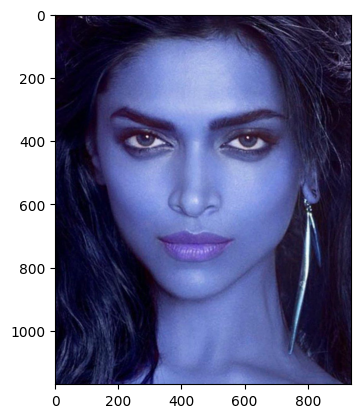

In [18]:
plt.imshow(img)

# Make a Gray image

In [19]:
gry= cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gry.shape

(1170, 936)

In [20]:
gry

array([[16, 15, 14, ..., 27, 31, 34],
       [14, 14, 13, ..., 26, 31, 34],
       [11, 11, 10, ..., 27, 32, 36],
       ...,
       [14, 17, 19, ..., 34, 42, 48],
       [15, 19, 23, ..., 31, 35, 38],
       [15, 19, 23, ..., 31, 35, 38]], shape=(1170, 936), dtype=uint8)

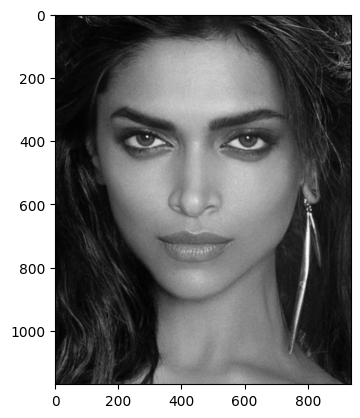

In [21]:
plt.imshow(gry, cmap='gray')

# import FACE abd EYE detction models from .xml file

In [22]:
pwd

'd:\\harshit python\\face detection\\Face-Recognition-image-processing-'

In [23]:
face_cascade = cv.CascadeClassifier("D:/harshit python/face detection/Face-Recognition-image-processing-/fac_eye_HAAR/haarcascade_frontalface_default.xml")   # detacts faces
eye_cascade = cv.CascadeClassifier("D:/harshit python/face detection/Face-Recognition-image-processing-/fac_eye_HAAR/haarcascade_eye.xml")   # detacts Eyes
fac = face_cascade.detectMultiScale(gry, 1.3, 5)   # face array of gray image
fac

array([[106, 152, 681, 681]], dtype=int32)

In [24]:
(x,y,w,h)= fac[0]
x,y,w,h

(np.int32(106), np.int32(152), np.int32(681), np.int32(681))

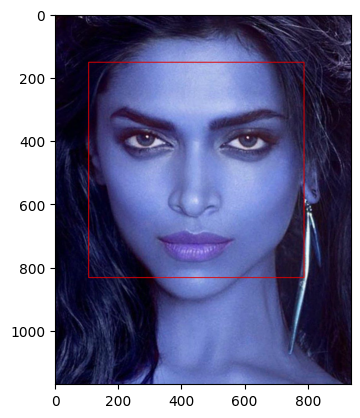

In [25]:
fac_img= cv.rectangle(img,(x,y),(x+w, y+h),(225,0,0),2) #225,0,0 is stands for RGB (for face squar)
plt.imshow(fac_img)

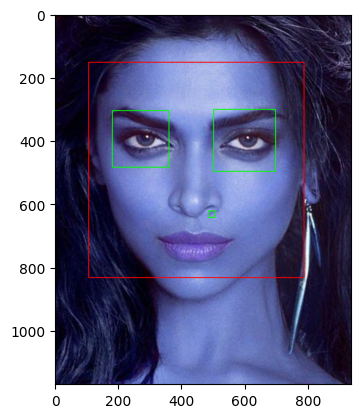

In [26]:
cv.destroyAllWindows()
for (x,y,w,h) in fac:
    fac_img = cv.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)       # 1st red squr image
    roi_gray = gry[y:y+h, x:x+w]                                  # croped gray image
    roi_color = fac_img[y:y+h, x:x+w]                             # croped 1st image
    eyes = eye_cascade.detectMultiScale(roi_gray)                 # EYE detaction model on gray image
    for (ex,ey,ew,eh) in eyes:                                    # ittration on arry of eyes
        cv.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2) # final green eye squr
                                                                  #roi=region of intrest :)

plt.figure()
plt.imshow(fac_img, cmap='gray')
plt.show()

In [27]:
eyes

array([[ 75, 153, 179, 179],
       [395, 149, 196, 196],
       [379, 470,  21,  21]], dtype=int32)

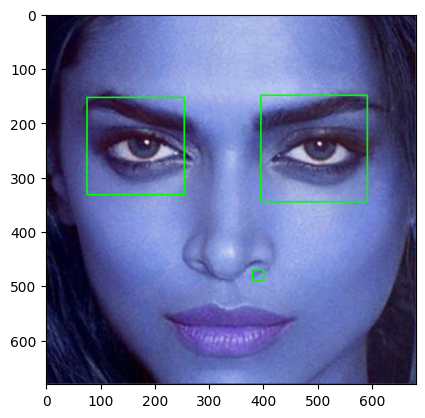

In [28]:
plt.imshow(roi_color)

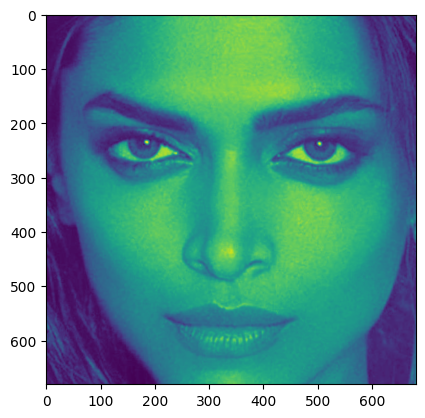

In [29]:
plt.imshow(roi_gray)

# i made a function of 'read img', 'gray img', 'face detact', 'eye detact' that returns the final croped face

In [30]:
def get_cropped_image_2_eyes(image_path):               # function name with arg
    img = cv.imread(image_path)                         # reads image as per path  
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY )         # creates gray image 
    faces = face_cascade.detectMultiScale(gray, 1.3, 5) # detacts face with .xml file 
    for (x,y,w,h) in faces:                             # recognise face square 
        roi_gray = gray[y:y+h, x:x+w]                   # gray sure image
        roi_color = img[y:y+h, x:x+w]                   # color suar image  
        eyes = eye_cascade.detectMultiScale(roi_gray)   # detacts eye with .xml file
        if len(eyes) >= 2:
            return roi_color                            # roi = region of interest :)

# lets try this function with nora -->

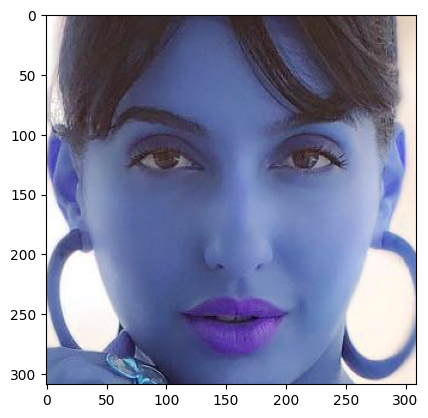

In [31]:
crp_img_test = get_cropped_image_2_eyes('D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Nora/1708306.jpg')
plt.imshow(crp_img_test)

In [32]:
path_to_data= "D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/"                 # Data path 
path_to_crp_data= "D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/"     # Path that will create folder named "cropped"

# collacting path of all individual folders and 
# stor that into list 

In [33]:
import os

In [34]:
img_dirs = []
for entry in os.scandir(path_to_data):          # Exact path of all data
    if entry.is_dir():                          #  Checks all paths 
        img_dirs.append(entry.path)             # all paths saved in list (Eg:next cell)

In [35]:
img_dirs

['D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Akshay',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Depika',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/kohli',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/messi',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Nora',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Sharapova',
 'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/data/Urvashi']

# creating croped folder 

In [36]:
import shutil                           # is the libray that coppys or select multipal path tree

In [37]:
if os.path.exists(path_to_crp_data):    
    shutil.rmtree(path_to_crp_data)
os.mkdir(path_to_crp_data)              # Creates the cropped folder as above path

In [38]:
cropped_image_dirs = []                                         # crop image path that will append with cropped folder
celeb_file_name_dict = {}                                       # will use to store final cropped img dict {key:val}

for img_dir in img_dirs:                                        # as above ittration on multiple paths                   
    celeb_name = img_dir.split('/')[-1]                         # seprates celebrity names from path(axay,dipika,kohli...)
    print(celeb_name)                                           # print celeb name in log 
    celeb_file_name_dict[celeb_name] = []                       # it will be like {('Depika': []')}
    count = 1
    
    for entry in os.scandir(img_dir):                           # here scaning of all image in folder Eg.(<DirEntry '00654a9bc.jpg'>)
        roi_color = get_cropped_image_2_eyes(entry.path)        # img goes in function with path Eg.('./face recognision/data/Urvashi/00654a9bc.jpg')
        if roi_color is not None:
            cropped_folder = path_to_crp_data + celeb_name      # './face recognision/data/cropped/ + Urvashi' -|
            if not os.path.exists(cropped_folder):              # is path is thare then start making dirs       |
                os.makedirs(cropped_folder)                     # maks dirs in cropped folder                   |
                cropped_image_dirs.append(cropped_folder)       #  crop img dir append with crop folder above  -|
                print("genrating cropped images in folder :", cropped_folder)  # print in log with crop folder path

            cropped_file_name = celeb_name + str(count) + ".png"               # creates img name with(akshay + 1 + .png)= akshay1.png
            cropped_file_path = cropped_folder + "/" + cropped_file_name       # inserting / in final path between folder and file names

            cv.imwrite(cropped_file_path, roi_color)                           # saveing img in perticuler name and location
            celeb_file_name_dict[celeb_name].append(cropped_file_path)                                                           # -|
            count += 1     

Akshay
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay
Depika
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Depika
kohli
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/kohli
messi
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/messi
Nora
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Nora
Sharapova
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Sharapova
Urvashi
genrating cropped images in folder : D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Urvashi


# Hre is Wavelet transform  
# to extract impo.features of an image

In [39]:
import pywt

In [40]:
def w2d(img, mode='haar', level=1):                                     # function with 'Haar' wavelent mode.(Datatype conversions)
    imArray = img                                                       # assaing image array to variable.
    imArray = cv.cvtColor( imArray,cv.COLOR_RGB2GRAY )                  # convert to grayscale
    imArray =  np.float32(imArray)                                      # convert to float  
    imArray /= 255;                                                     # image array divided by 255 to make better coefficients
    coeffs=pywt.wavedec2(imArray, mode, level=level)                    # compute coefficients.(it is lavel=1 we can go further till lavel=any)

    coeffs_H=list(coeffs)                                               # Process Coefficients(putting into list)easy for *0
    coeffs_H[0] *= 0;                                                   # *0

    # reconstruction

    imArray_H=pywt.waverec2(coeffs_H, mode);                            # waverec2 for reconstruction of image array 
    imArray_H *= 255;                                                   # '*' img array with 255 as per R.G.B.
    imArray_H =  np.uint8(imArray_H)                                    # seted units for 8.bit to display

    return imArray_H

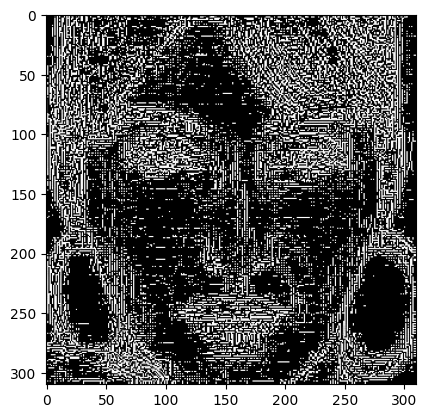

In [41]:
img_har = w2d(crp_img_test,'db1',1)
plt.imshow(img_har,cmap='gray')

# Diffrent lavels of wavelent transform

Here algo. Applys LOW PASS and HIGH PASS Filters and Scale Down Signal(by.2) at Each Lavel

Text(0.5, 1.0, 'lavel 5')

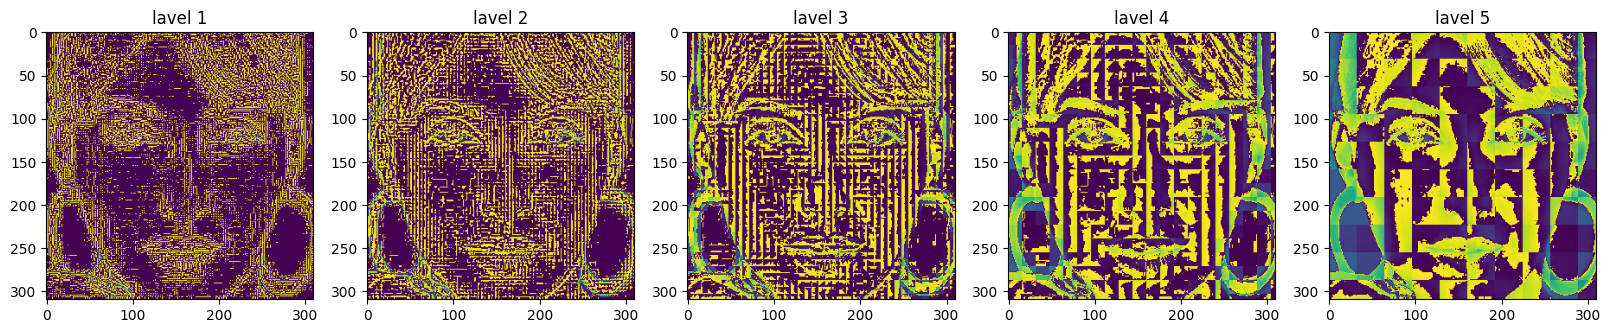

In [42]:
img_har1 = w2d(crp_img_test,'db1',2)
img_har2= w2d(crp_img_test,'db1',3)
img_har3 = w2d(crp_img_test,'db1',4)
img_har4 = w2d(crp_img_test,'db1',5)

fig = plt.figure(figsize=(20,15))
ax1 = fig.add_subplot(1,5,1)
ax1.imshow(img_har)
plt.title("lavel 1")
ax2 = fig.add_subplot(1,5,2)
ax2.imshow(img_har1)
plt.title("lavel 2")
ax3 = fig.add_subplot(1,5,3)
ax3.imshow(img_har2)
plt.title("lavel 3")
ax4 = fig.add_subplot(1,5,4)
ax4.imshow(img_har3)
plt.title("lavel 4")
ax5 = fig.add_subplot(1,5,5)
ax5.imshow(img_har4)
plt.title("lavel 5")

# Re-construct celeb_file_name_dict after manual deleting images

In [43]:
celeb_file_name_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celeb_file_name_dict[celebrity_name] = file_list
celeb_file_name_dict

{'Akshay': ['D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay1.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay10.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay11.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay12.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay13.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay14.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay15.png',
  'D:/harshit python/face detection/Face-Recognition-image-processing-/face_rec_data/cropped/Akshay\\Akshay16.png',
  'D:/harshit python/face detection/Face-Recognition-image-proc

# Here we give number to celebrity name; just like encodeing

In [44]:
class_dict = {}
count = 0
for celebrity_name in celeb_file_name_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'Akshay': 0,
 'Depika': 1,
 'kohli': 2,
 'messi': 3,
 'Nora': 4,
 'Sharapova': 5,
 'Urvashi': 6}

#  here we vertically stacking images and creating X,Y for training

In [45]:
X, y = [], []

for celebrity_name, training_files in celeb_file_name_dict.items():                  # 1st loor celab.name and 2nd for perticular images 
    for training_image in training_files:                                            # ittration on celeb.img
        img = cv.imread(training_image)                                              # reading img in perticular celeb.folder
        
        scalled_raw_img = cv.resize(img, (32, 32))                                   # resizing raw cropped image
        img_har = w2d(img,'db1',5)                                                   # applying wavelent transformation
        scalled_img_har = cv.resize(img_har, (32, 32))                               # resizing raw transformed image
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))         # vertically stacking image with inbuilt numpy.vstack function
        # (32*32*3,1)=here is R.G.B.(3Daimantin)||(32*32,1)=here is 1Daimention
        
        X.append(combined_img)
        y.append(class_dict[celebrity_name])  

In [46]:
len(X[1])

4096

In [47]:
32*32*3 + 32*32

4096

In [48]:
X[1]

array([[ 22],
       [ 28],
       [ 40],
       ...,
       [ 10],
       [255],
       [  0]], shape=(4096, 1), dtype=uint8)

# converting int into float 

In [49]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(420, 4096)

#import modelsand needed librarys

In [50]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report


# here is model training with pipeline 

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'linear', C = 11))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)


0.7333333333333333

In [52]:
print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.81      0.76      0.79        17
           1       0.72      0.81      0.76        16
           2       0.85      0.69      0.76        16
           3       0.62      0.73      0.67        11
           4       0.40      0.57      0.47         7
           5       0.83      1.00      0.91         5
           6       0.79      0.70      0.74        33

    accuracy                           0.73       105
   macro avg       0.72      0.75      0.73       105
weighted avg       0.75      0.73      0.74       105



In [53]:
cm = confusion_matrix(y_test, pipe.predict(X_test))
cm

array([[13,  0,  0,  1,  1,  0,  2],
       [ 0, 13,  1,  0,  1,  0,  1],
       [ 1,  1, 11,  3,  0,  0,  0],
       [ 0,  0,  1,  8,  0,  0,  2],
       [ 1,  1,  0,  0,  4,  0,  1],
       [ 0,  0,  0,  0,  0,  5,  0],
       [ 1,  3,  0,  1,  4,  1, 23]])

Text(95.72222222222221, 0.5, 'Truth')

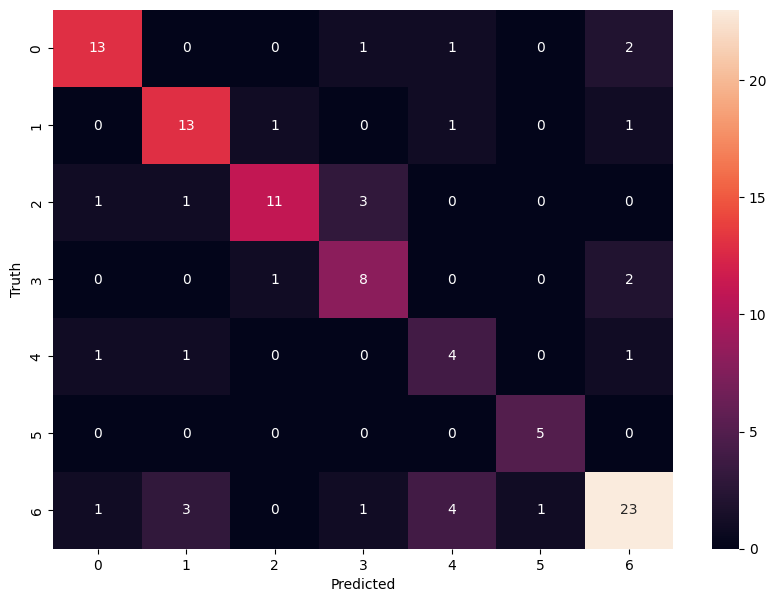

In [54]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

# save trained model 

In [55]:
import joblib 
# Save the model as a pickle in a file 
joblib.dump(pipe, 'saved_model.pkl') 

['saved_model.pkl']

# save Json directory

In [56]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))